# Transformers and Accelerate
Demonstration of easy model usage and device placement.

In [1]:
from transformers import pipeline, AutoModelForCausalLM, AutoTokenizer
import torch
import matplotlib.pyplot as plt
import time

# Using a pipeline
device = "mps" if torch.backends.mps.is_available() else "cpu"
classifier = pipeline("sentiment-analysis", device=device)
print(classifier("We are thrilled to be at Thoughtworks Madrid!"))

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Device set to use mps


[{'label': 'POSITIVE', 'score': 0.9998226761817932}]


Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Hugging Face is a game that is a bit of a mess. It's a game where you have to make a


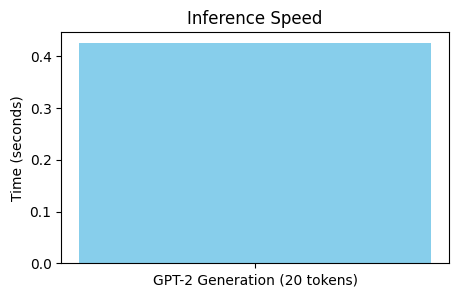

In [2]:
# Using Accelerate implicitly via device_map="auto" (requires accelerate library)
model_id = "openai-community/gpt2"
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_id)

inputs = tokenizer("Hugging Face is", return_tensors="pt").to(model.device)

# Benchmark generation speed
start_time = time.time()
outputs = model.generate(**inputs, max_new_tokens=20)
end_time = time.time()

print(tokenizer.decode(outputs[0], skip_special_tokens=True))

plt.figure(figsize=(5,3))
plt.bar(["GPT-2 Generation (20 tokens)"], [end_time - start_time], color="skyblue")
plt.ylabel("Time (seconds)")
plt.title("Inference Speed")
plt.show()